In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split
import data_generator_update as data2
sns.set_style("whitegrid")

In [ ]:
seed = 100
n_pop = 1000
n_holdout = 2000
features = ['X1','X2','X3','X4','X5']     # features used for business_score & selection X-part
weights = np.array([0.5, 0.3, 0.1, 0.05, 0.05])
weights = weights / (weights.sum() + 1e-12)

# MNAR: moderate X strength + moderate Y influence
beta_x_scale = 3.0        # increase X-part strength moderately
beta_y_mnar = -2.0        # negative -> BAD (Y=1) less likely accepted

# MIXED config: mostly X but Y contributes a little
alpha_mixed = 0.20        # 20% of score comes from Y-term
beta_y_mixed = -2.0 
# selection: probabilistic (sigmoid->Bernoulli) tuned to this mean acceptance rate
target_accept_rate = 0.20
rng_seed = 12345  # used for selection randomness

# IPW clip eps
ipw_eps = 1e-3

In [37]:
# ---------------- Create population & holdout ----------------
res = data2.DataGenerator2(
    n = n_pop,
    k_con = 10,
    k_bin = 1,
    bad_ratio = 0.8,
    con_mean_bad_dif = [-0.5,1.0,1.2,0.0,0.9,-0.2,1.5,0.4,0.3,0.8],
    seed = seed,
    coef_scale = 1.0,
    noise_scale = 1.0,
    flip_frac = 0.0,
    verbose = False
)
df_full = res.generate()
holdout = data2.DataGenerator2(n=n_holdout, replicate=res, seed=99999, verbose=False)
holdout.generate()
holdout_df = holdout.data.copy()

In [38]:
# numeric labels
df_full['Y'] = df_full['BAD'].map({'GOOD':0,'BAD':1}).astype(int)
holdout_df['Y'] = holdout_df['BAD'].map({'GOOD':0,'BAD':1}).astype(int)

In [40]:
# standardize selected features on population and compute business_score
scaler = StandardScaler().fit(df_full[features].astype(float).values)
Xz_full = scaler.transform(df_full[features].astype(float).values)
df_full['business_score'] = Xz_full.dot(weights)


# build beta_x aligned to business_score and scale X strength
all_X_cols = [c for c in df_full.columns if c.startswith('X')]
beta_x_base = np.zeros(len(all_X_cols), dtype=float)
for i, f in enumerate(features):
    beta_x_base[i] = weights[i]
beta_x = beta_x_base * float(beta_x_scale)

In [41]:
#create probabilistic MNAR observed dataset
df_full_mnar, df_obs_mnar = res.impose_selection(
    mode='MNAR',
    top_percent=None,
    beta_x=beta_x,
    beta_y=float(beta_y_mnar),
    target_accept_rate=float(target_accept_rate),
    probabilistic=True,
    stochastic=True,
    rng_seed=rng_seed
)
df_obs_mnar = df_obs_mnar.copy()
df_obs_mnar['business_score'] = df_full['business_score'].values

In [42]:
# ---------------- create probabilistic MIXED observed dataset ----------------
df_full_mix, df_obs_mix = res.impose_selection(
    mode='MIXED',
    top_percent=None,
    beta_x=beta_x,
    beta_y=float(beta_y_mixed),
    alpha=float(alpha_mixed),
    target_accept_rate=float(target_accept_rate),
    probabilistic=True,
    stochastic=True,
    rng_seed=rng_seed
)
df_obs_mix = df_obs_mix.copy()
df_obs_mix['business_score'] = df_full['business_score'].values

In [47]:
def add_ipw(df_obs, eps=1e-3):
    if 'p_accept' not in df_obs.columns:
        raise RuntimeError("p_accept missing. Selection must be probabilistic to compute IPW.")
    p = df_obs['p_accept'].astype(float).values
    p_clipped = np.clip(p, eps, 1.0)
    ipw = 1.0 / p_clipped
    # normalize ipw among accepted rows so sum(ipw) ~= n_accept
    ipw_norm = ipw.copy()
    acc_idx = (df_obs['S'] == 1).values
    n_acc = acc_idx.sum()
    if n_acc > 0 and ipw[acc_idx].sum() > 0:
        ipw_norm[acc_idx] = ipw[acc_idx] * (n_acc / np.sum(ipw[acc_idx]))
    df_obs['p_accept'] = p
    df_obs['ipw'] = ipw
    df_obs['ipw_norm'] = ipw_norm
    return df_obs

df_obs_mnar = add_ipw(df_obs_mnar, eps=ipw_eps)
df_obs_mix  = add_ipw(df_obs_mix,  eps=ipw_eps)

In [49]:
# ---------------- 5) quick sanity diagnostics (print) ----------------
def print_diag(df_full_local, df_obs_local, name):
    print("----", name, "----")
    print("population n:", len(df_full_local))
    print("observed accepted:", int(df_obs_local['S'].sum()), " (~", df_obs_local['S'].mean(), "accept rate )")
    print("P(R=1 | Y):", df_obs_local.groupby('Y')['S'].mean().to_dict())
    print("accepted counts by Y:", df_obs_local.loc[df_obs_local['S']==1,'Y'].value_counts().to_dict())
    print()

print_diag(df_full_mnar, df_obs_mnar, "MNAR (probabilistic)")
print_diag(df_full_mix, df_obs_mix, f"MIXED (alpha={alpha_mixed}, probabilistic)")


---- MNAR (probabilistic) ----
population n: 1000
observed accepted: 190  (~ 0.19 accept rate )
P(R=1 | Y): {0: 0.3627450980392157, 1: 0.1457286432160804}
accepted counts by Y: {1: 116, 0: 74}

---- MIXED (alpha=0.2, probabilistic) ----
population n: 1000
observed accepted: 188  (~ 0.188 accept rate )
P(R=1 | Y): {0: 0.20588235294117646, 1: 0.18341708542713567}
accepted counts by Y: {1: 146, 0: 42}



In [50]:
df_full_mnar.to_csv("full_mnar.csv", index=False)
df_obs_mnar.to_csv("obs_mnar.csv", index=False)
df_full_mix.to_csv("full_mix.csv", index=False)
df_obs_mix.to_csv("obs_mix.csv", index=False)
holdout_df.to_csv("holdout.csv", index=False)

In [51]:
df_obs_mnar = df_obs_mnar.copy()
df_obs_mix  = df_obs_mix.copy()
df_obs_mnar['business_score'] = df_full_mnar['business_score'].values
df_obs_mix['business_score']  = df_full_mix['business_score'].values

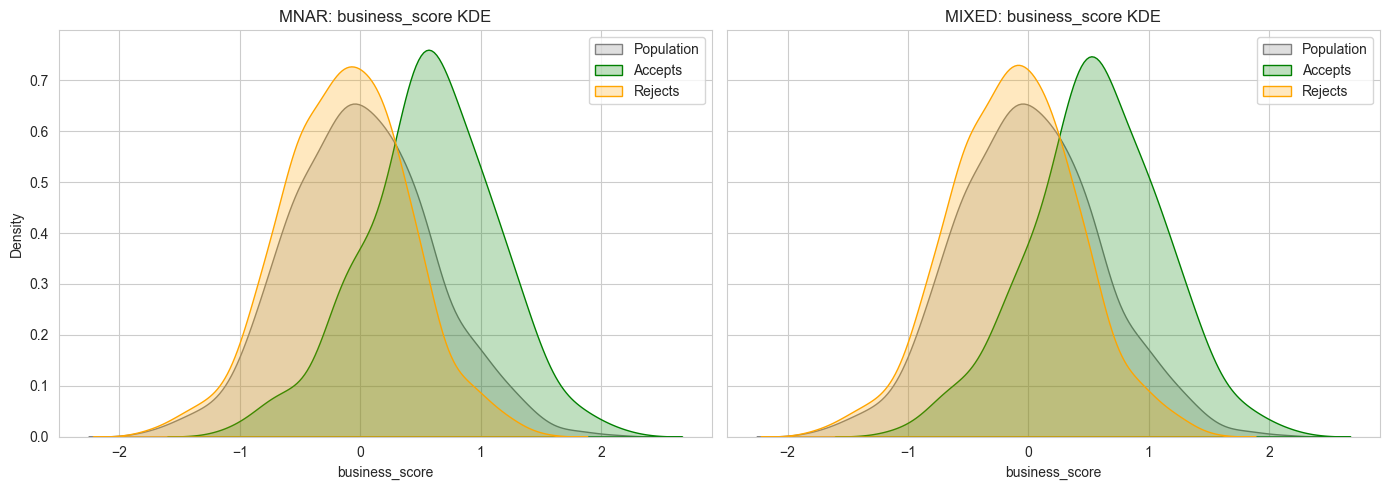

In [45]:
fig, axes = plt.subplots(1,2, figsize=(14,5), sharey=True)
sns.kdeplot(df_full_mnar['business_score'], fill=True, color='gray', ax=axes[0], label='Population')
sns.kdeplot(df_obs_mnar.loc[df_obs_mnar['S']==1,'business_score'], fill=True, color='green', ax=axes[0], label='Accepts')
sns.kdeplot(df_obs_mnar.loc[df_obs_mnar['S']==0,'business_score'], fill=True, color='orange', ax=axes[0], label='Rejects')
axes[0].set_title('MNAR: business_score KDE')
axes[0].legend()

sns.kdeplot(df_full_mix['business_score'], fill=True, color='gray', ax=axes[1], label='Population')
sns.kdeplot(df_obs_mix.loc[df_obs_mix['S']==1,'business_score'], fill=True, color='green', ax=axes[1], label='Accepts')
sns.kdeplot(df_obs_mix.loc[df_obs_mix['S']==0,'business_score'], fill=True, color='orange', ax=axes[1], label='Rejects')
axes[1].set_title('MIXED: business_score KDE')
axes[1].legend()

plt.tight_layout()
plt.show()

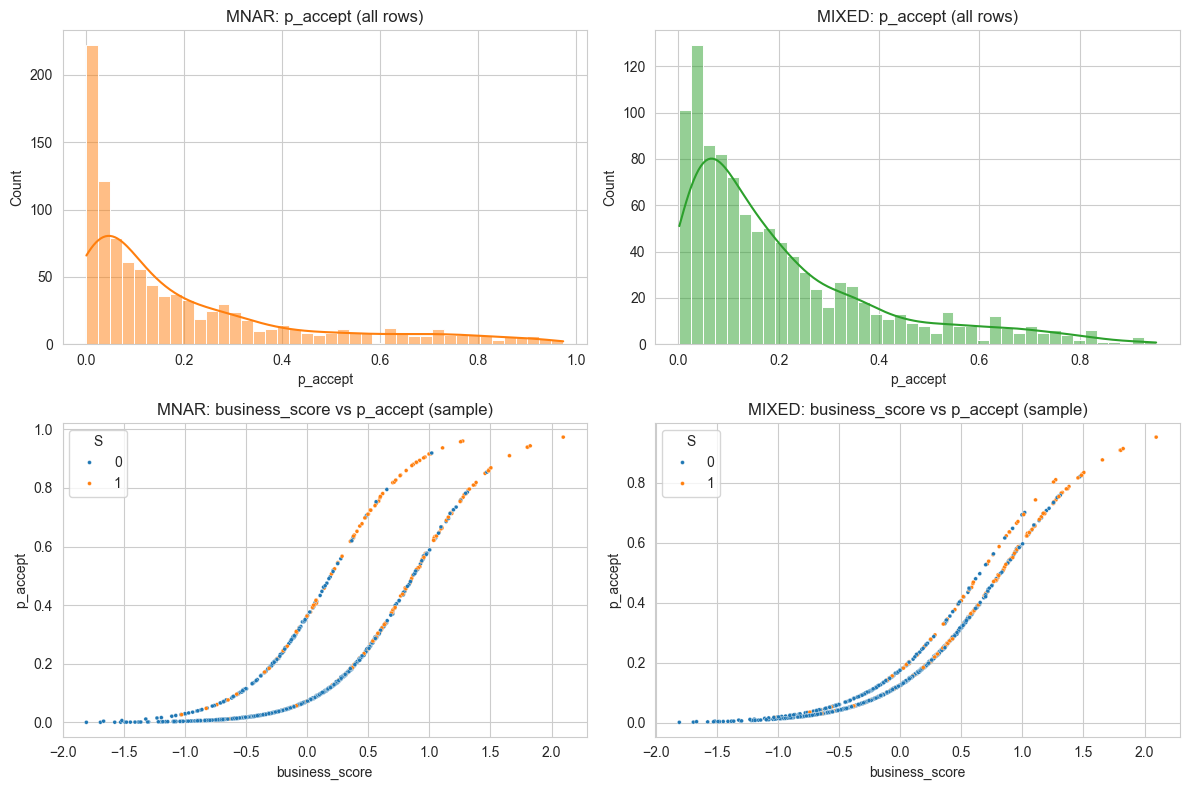

In [46]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
sns.histplot(df_obs_mnar['p_accept'], bins=40, kde=True, ax=axes[0,0], color='C1')
axes[0,0].set_title('MNAR: p_accept (all rows)')

sns.scatterplot(x='business_score', y='p_accept', hue='S', data=df_obs_mnar.sample(min(len(df_obs_mnar),2000)), ax=axes[1,0], s=8)
axes[1,0].set_title('MNAR: business_score vs p_accept (sample)')

sns.histplot(df_obs_mix['p_accept'], bins=40, kde=True, ax=axes[0,1], color='C2')
axes[0,1].set_title('MIXED: p_accept (all rows)')

sns.scatterplot(x='business_score', y='p_accept', hue='S', data=df_obs_mix.sample(min(len(df_obs_mix),2000)), ax=axes[1,1], s=8)
axes[1,1].set_title('MIXED: business_score vs p_accept (sample)')

plt.tight_layout()
plt.show()